# Exercice 6 - Apprentissage supervisé

## Dataset : Pokemon with stats

URL : https://www.kaggle.com/datasets/abcsds/pokemon

Nous avons choisi un dataset qui regroupe les Pokémon des six premières générations avec leurs types et leurs statistiques de combat. Le fichier téléchargé contient 800 lignes, car certains Pokémon apparaissent aussi sous une forme différente, par exemple en Méga-Évolution.

## Objectif supervisé

Dans cet exercice, on cherche à prédire le type principal d'un Pokémon (`Type 1`) à partir de six statistiques : `HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def` et `Speed`.

Il s'agit d'une classification multiclasse puisqu'il existe 18 types possibles. L'idée est surtout de voir si les statistiques de combat suffisent à donner une indication sur le type d'un Pokémon.

Les six variables utilisées sont exprimées en points de statistique, sans unité physique :
- `HP` représente les points de vie du Pokémon ;
- `Attack` et `Defense` représentent ses capacités d'attaque et de défense physiques
- `Sp. Atk` et `Sp. Def` représentent ses capacités d'attaque et de défense spéciales
- `Speed` représente sa vitesse, qui intervient notamment dans l'ordre des actions pendant un combat.

## Imports et configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Chargement des données

On télécharge directement le dataset depuis Kaggle avec `kagglehub`, puis on récupère le fichier CSV contenu dans le dossier téléchargé.

In [2]:
import kagglehub

dataset_dir = Path(kagglehub.dataset_download("abcsds/pokemon"))
csv_paths = sorted(dataset_dir.rglob("*.csv"))

if not csv_paths:
    raise FileNotFoundError("Aucun fichier CSV trouvé.")

data_path = csv_paths[0]
df = pd.read_csv(data_path)

print(f"Dataset chargé depuis : {data_path}")
df.head()

Dataset chargé depuis : /home/coco_ayano/.cache/kagglehub/datasets/abcsds/pokemon/versions/2/Pokemon.csv


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Suppression des Méga-Évolutions et des formes alternatives

Le fichier contient 800 lignes, mais seulement 721 numéros de Pokédex différents. Cela vient surtout des Méga-Évolutions et des autres formes alternatives, qui gardent le même numéro que le Pokémon de base.

Nous avons donc choisi de garder la première ligne de chaque numéro de Pokédex. De cette manière, un Pokémon n'est compté qu'une seule fois et deux formes très proches ne peuvent pas se retrouver l'une dans le train et l'autre dans le test. Après ce nettoyage, il reste bien 721 lignes.

In [3]:
initial_row_count = len(df)
df = df.drop_duplicates(subset="#", keep="first").reset_index(drop=True)

print(f"Nombre de lignes avant le nettoyage : {initial_row_count}")
print(f"Nombre de lignes après le nettoyage : {len(df)}")
print(f"Nombre de numéros de Pokédex uniques : {df['#'].nunique()}")

Nombre de lignes avant le nettoyage : 800
Nombre de lignes après le nettoyage : 721
Nombre de numéros de Pokédex uniques : 721


## Vérification des variables utilisées

On garde seulement les six statistiques de combat choisies au départ. Le nom, le numéro, la génération et le statut légendaire ne sont pas utilisés pour faire la prédiction.

In [4]:
feature_columns = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
target_column = "Type 1"

required_columns = feature_columns + [target_column]
missing_columns = sorted(set(required_columns) - set(df.columns))
if missing_columns:
    raise ValueError(f"Colonnes manquantes dans le dataset : {missing_columns}")

data = df[required_columns].copy()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 721 entries, 0 to 720
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   HP       721 non-null    int64
 1   Attack   721 non-null    int64
 2   Defense  721 non-null    int64
 3   Sp. Atk  721 non-null    int64
 4   Sp. Def  721 non-null    int64
 5   Speed    721 non-null    int64
 6   Type 1   721 non-null    str  
dtypes: int64(6), str(1)
memory usage: 39.6 KB


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
HP,721.0,68.380028,25.848272,1.0,50.0,65.0,80.0,255.0
Attack,721.0,75.124827,29.070335,5.0,54.0,75.0,95.0,165.0
Defense,721.0,70.697642,29.194941,5.0,50.0,65.0,85.0,230.0
Sp. Atk,721.0,68.848821,28.898590,10.0,45.0,65.0,90.0,154.0
Sp. Def,721.0,69.180305,26.899364,20.0,50.0,65.0,85.0,230.0
Speed,721.0,65.714286,27.277920,5.0,45.0,65.0,85.0,160.0


In [6]:
data.isna().sum().to_frame("missing_values")

,missing_values
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0
Type 1,0


## Analyse descriptive

Avant d'entraîner les modèles, on regarde la répartition des types, la forme des variables et les liens possibles entre les statistiques.

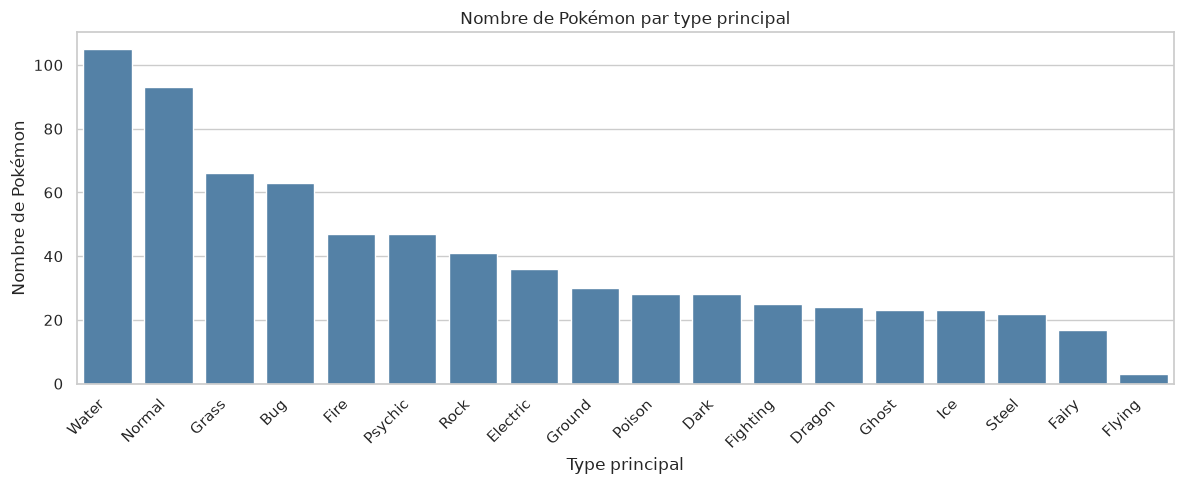

,count
Type 1,
Water,105
Normal,93
Grass,66
Bug,63
Fire,47
Psychic,47
Rock,41
Electric,36
Ground,30


In [7]:
type_counts = data[target_column].value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, color="steelblue")
plt.title("Nombre de Pokémon par type principal")
plt.xlabel("Type principal")
plt.ylabel("Nombre de Pokémon")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

type_counts.to_frame("count")

### Répartition des types

On voit que les classes sont assez déséquilibrées. Les types `Water` et `Normal` sont les plus présents, avec respectivement 105 et 93 Pokémon, alors que le type `Flying` n'apparaît que 3 fois comme type principal. Il faudra donc éviter de juger les modèles uniquement avec l'accuracy, car les types les plus fréquents pourraient avoir trop de poids dans le résultat.

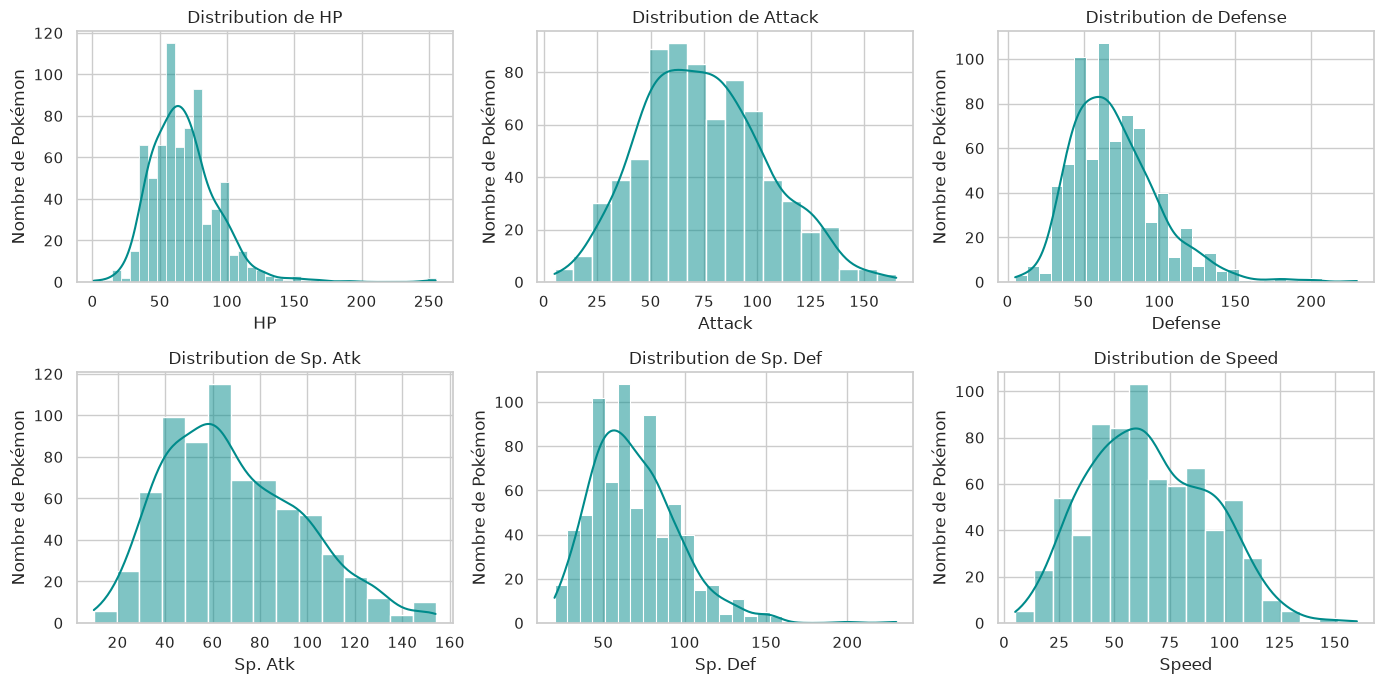

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, column in zip(axes.ravel(), feature_columns):
    sns.histplot(data=data, x=column, kde=True, ax=ax, color="darkcyan")
    ax.set_title(f"Distribution de {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Nombre de Pokémon")

plt.tight_layout()
plt.show()

### Distribution des statistiques

La plupart des statistiques sont concentrées autour de valeurs moyennes, mais on remarque aussi quelques Pokémon avec des valeurs beaucoup plus élevées. C'est particulièrement visible pour les points de vie et la défense, dont les distributions sont étirées vers la droite. Ces valeurs extrêmes ne sont pas forcément des erreurs : elles correspondent à des Pokémon qui ont réellement des statistiques très particulières. Nous avons donc choisi de les conserver.

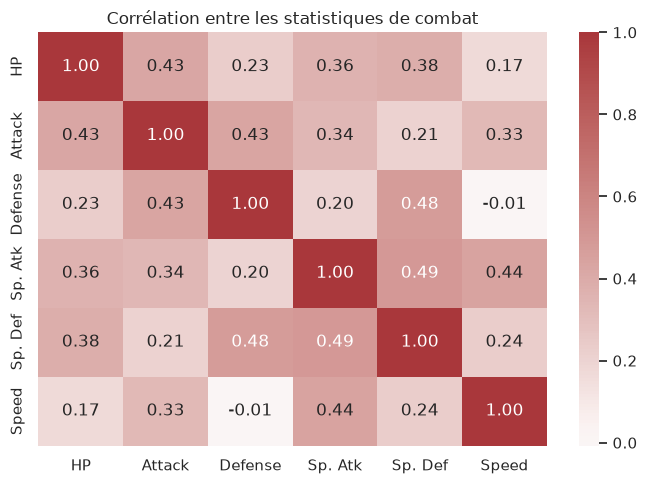

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(data[feature_columns].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Corrélation entre les statistiques de combat")
plt.tight_layout()
plt.show()

### Corrélations entre les statistiques

Les corrélations sont globalement faibles ou moyennes. Les plus fortes sont entre l'attaque spéciale et la défense spéciale (`0.49`), puis entre la défense et la défense spéciale (`0.48`). La vitesse et la défense sont presque indépendantes dans ce dataset, avec une corrélation proche de `0`. Aucune paire n'est très fortement corrélée, donc les six statistiques peuvent apporter des informations différentes au modèle.

## Séparation train / test

On sépare 25 % des données pour le test. Ces données ne servent pas à choisir le modèle : elles sont gardées de côté pour l'évaluation finale. L'option `stratify=y` permet de conserver au mieux la proportion de chaque type dans les deux groupes.

In [10]:
X = data[feature_columns]
y = data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train set : {X_train.shape[0]} lignes")
print(f"Test set  : {X_test.shape[0]} lignes")
print(f"Nombre de classes : {y.nunique()}")

Train set : 540 lignes
Test set  : 181 lignes
Nombre de classes : 18


## Prétraitement et modèles comparés

Toutes les variables utilisées sont numériques. On les standardise dans un `Pipeline` pour les mettre sur une échelle comparable. Le `Pipeline` permet aussi de calculer cette transformation uniquement avec les données d'entraînement.

Nous avons comparé plusieurs modèles assez différents :
- `DummyClassifier`, qui donne un score de référence très simple ;
- `LogisticRegression`, qui est un modèle linéaire ;
- `SVC` avec un noyau RBF, qui peut apprendre des séparations non linéaires ;
- `KNeighborsClassifier`, qui se base sur les Pokémon les plus proches ;
- `RandomForestClassifier`, qui combine plusieurs arbres de décision.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[("numeric", StandardScaler(), feature_columns)],
    remainder="drop",
)

model_configs = {
    "Dummy": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]),
        "params": {},
    },
    "Logistic regression": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        ]),
        "params": {"model__C": [0.1, 1.0, 10.0]},
    },
    "SVC RBF": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", SVC(kernel="rbf", random_state=RANDOM_STATE)),
        ]),
        "params": {
            "model__C": [0.1, 1.0, 10.0],
            "model__gamma": ["scale", 0.01, 0.1],
        },
    },
    "KNN": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", KNeighborsClassifier()),
        ]),
        "params": {"model__n_neighbors": [3, 5, 9, 15]},
    },
    "Random forest": {
        "pipeline": Pipeline([
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 3],
        },
    },
}

## Validation croisée et choix des hyperparamètres

Pour choisir le meilleur modèle, on regarde surtout le F1-score macro. Il calcule un score pour chaque type avant d'en faire la moyenne, donc les types rares ne sont pas oubliés. On affiche aussi l'accuracy, mais elle peut être trompeuse ici puisqu'un modèle peut obtenir un score correct en favorisant les types les plus nombreux.

In [12]:
min_class_count = int(y_train.value_counts().min())
n_splits = min(5, min_class_count)

if n_splits < 2:
    raise ValueError("Pas assez d'exemples par classe pour effectuer une validation croisée stratifiée.")

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

best_estimators = {}
cv_rows = []

for model_name, config in model_configs.items():
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        scoring=scoring,
        refit="f1_macro",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    best_estimators[model_name] = search.best_estimator_
    cv_rows.append({
        "model": model_name,
        "best_params": search.best_params_,
        "cv_accuracy_mean": search.cv_results_["mean_test_accuracy"][search.best_index_],
        "cv_balanced_accuracy_mean": search.cv_results_["mean_test_balanced_accuracy"][search.best_index_],
        "cv_f1_macro_mean": search.best_score_,
        "train_f1_macro_mean": search.cv_results_["mean_train_f1_macro"][search.best_index_],
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1_macro_mean", ascending=False)
cv_results

,model,best_params,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_f1_macro_mean,train_f1_macro_mean
2,SVC RBF,"{'model__C': 10.0, 'model__gamma': 0.1}",0.231481,0.171574,0.169168,0.595170
4,Random forest,"{'model__max_depth': None, 'model__min_samples...",0.225926,0.168046,0.167470,0.990657
1,Logistic regression,{'model__C': 1.0},0.240741,0.157069,0.145082,0.182169
3,KNN,{'model__n_neighbors': 3},0.175926,0.143099,0.131591,0.409979
0,Dummy,{},0.146296,0.055556,0.014180,0.014180


### Limite de la validation croisée

Après la séparation train/test, il ne reste que deux Pokémon de type principal `Flying` dans le jeu d'entraînement. Pour que chaque partie de la validation contienne au moins un exemple de chaque type, la validation croisée est donc limitée à 2 folds au lieu de 5. Cela permet de garder une validation stratifiée, mais les scores peuvent varier davantage qu'avec un plus grand nombre de folds. Il faut donc les interpréter avec prudence.

## Évaluation finale sur le jeu de test

Une fois les meilleurs hyperparamètres trouvés, on compare les modèles sur les données de test qui n'ont pas servi pendant la validation croisée.

In [13]:
test_rows = []

for model_name, estimator in best_estimators.items():
    y_pred = estimator.predict(X_test)
    test_rows.append({
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
    })

test_results = pd.DataFrame(test_rows).sort_values("test_f1_macro", ascending=False)
test_results

,model,test_accuracy,test_balanced_accuracy,test_f1_macro
2,SVC RBF,0.281768,0.230627,0.228214
3,KNN,0.198895,0.180978,0.165179
4,Random forest,0.237569,0.162340,0.143203
1,Logistic regression,0.215470,0.146361,0.136554
0,Dummy,0.143646,0.055556,0.013956


In [14]:
selected_model_name = cv_results.iloc[0]["model"]
selected_model = best_estimators[selected_model_name]
selected_predictions = selected_model.predict(X_test)

print(f"Modèle sélectionné par validation croisée : {selected_model_name}")
print(classification_report(y_test, selected_predictions))

Modèle sélectionné par validation croisée : SVC RBF
              precision    recall  f1-score   support

         Bug       0.28      0.31      0.29        16
        Dark       0.00      0.00      0.00         7
      Dragon       0.33      0.17      0.22         6
    Electric       0.23      0.33      0.27         9
       Fairy       0.67      0.50      0.57         4
    Fighting       0.25      0.17      0.20         6
        Fire       0.21      0.33      0.26        12
      Flying       0.00      0.00      0.00         1
       Ghost       0.00      0.00      0.00         6
       Grass       0.35      0.35      0.35        17
      Ground       0.67      0.50      0.57         8
         Ice       0.00      0.00      0.00         6
      Normal       0.33      0.52      0.41        23
      Poison       0.00      0.00      0.00         7
     Psychic       0.44      0.33      0.38        12
        Rock       0.20      0.20      0.20        10
       Steel       0.14      

/home/coco_ayano/ING2/FML/git_projet/FTML_project/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/coco_ayano/ING2/FML/git_projet/FTML_project/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/coco_ayano/ING2/FML/git_projet/FTML_project/env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

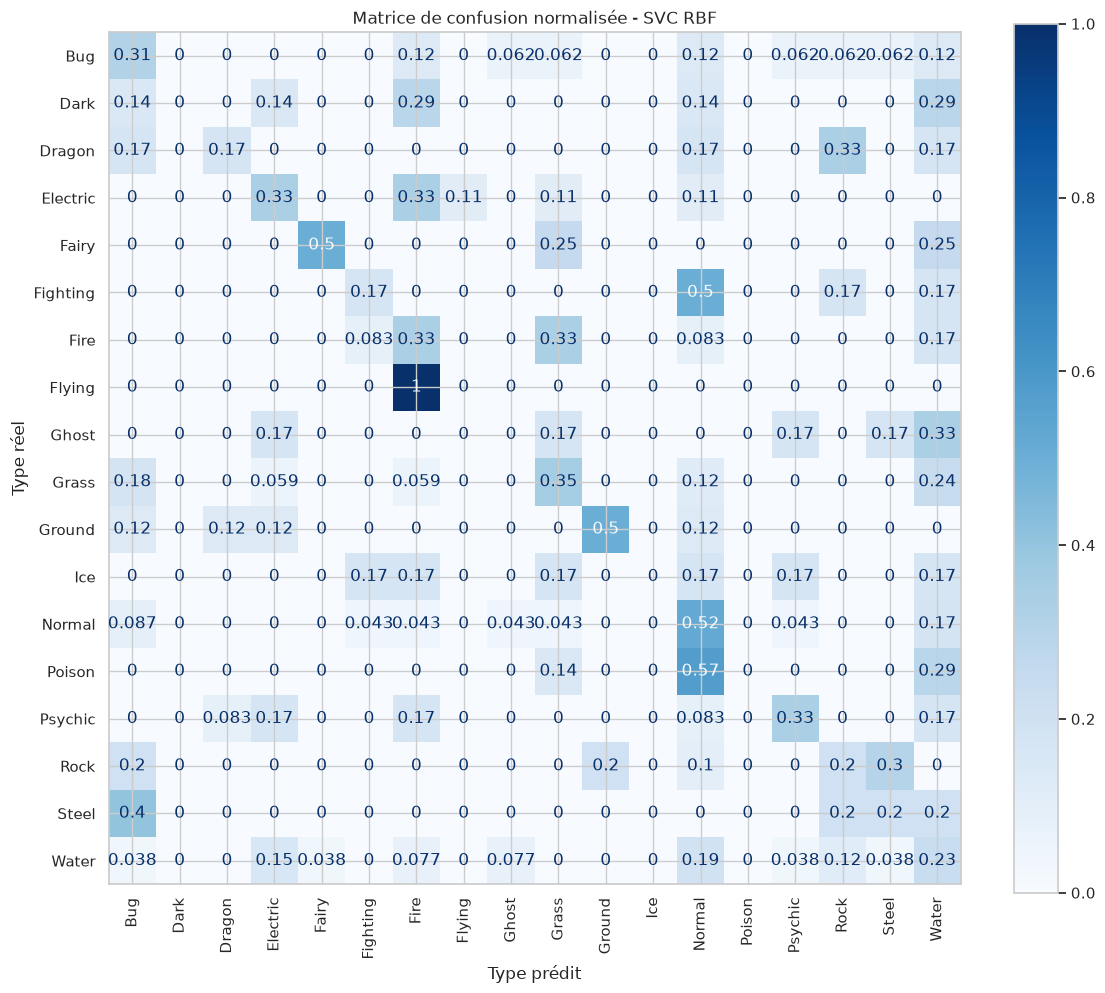

In [15]:
labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(
    selected_model,
    X_test,
    y_test,
    labels=labels,
    normalize="true",
    cmap="Blues",
    xticks_rotation=90,
    ax=ax,
)
ax.set_title(f"Matrice de confusion normalisée - {selected_model_name}")
ax.set_xlabel("Type prédit")
ax.set_ylabel("Type réel")
plt.tight_layout()
plt.show()

## Importance des variables

Pour avoir une idée des variables les plus utiles, on mélange leurs valeurs une par une et on regarde si le score du modèle diminue. Si la baisse est importante, cela veut dire que le modèle avait besoin de cette variable pour faire ses prédictions.

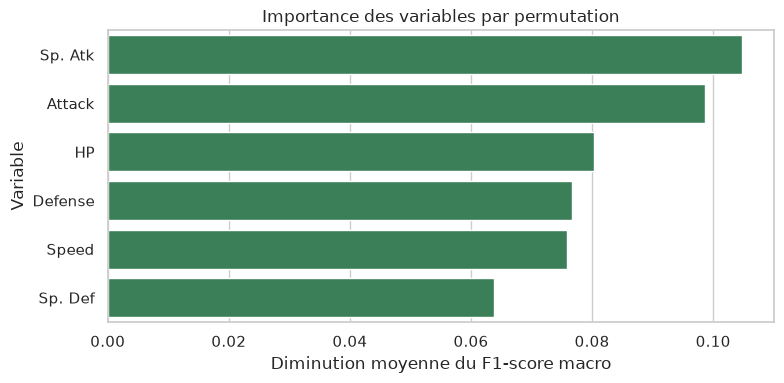

,feature,importance_mean,importance_std
3,Sp. Atk,0.104806,0.013689
1,Attack,0.098710,0.017569
0,HP,0.080251,0.023306
2,Defense,0.076633,0.020418
5,Speed,0.075797,0.022105
4,Sp. Def,0.063790,0.018555


In [16]:
importance = permutation_importance(
    selected_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x="importance_mean", y="feature", color="seagreen")
plt.xlabel("Diminution moyenne du F1-score macro")
plt.ylabel("Variable")
plt.title("Importance des variables par permutation")
plt.tight_layout()
plt.show()

importance_df

## Discussion des résultats

D'après la validation croisée, le meilleur modèle est le `SVC` avec un noyau RBF, pour `C = 10` et `gamma = 0.1`. Son F1-score macro est d'environ `0.17` pendant la validation, alors qu'il atteint presque `0.60` sur les données d'entraînement. On peut donc penser que le modèle apprend assez bien les données qu'il connaît déjà, mais qu'il a plus de mal avec de nouveaux Pokémon.

Sur le jeu de test, le SVC obtient environ `28 %` d'accuracy et un F1-score macro de `0.23`. C'est nettement mieux que le `DummyClassifier`, mais cela reste faible pour faire une prédiction vraiment fiable. La Random Forest semble presque parfaite sur le train, mais ses résultats chutent fortement en validation et sur le test. Elle est donc clairement en situation de surapprentissage.

Le rapport de classification montre aussi que les résultats changent beaucoup selon le type. `Fairy` et `Ground` sont plutôt bien reconnus dans ce test, tandis que `Dark`, `Flying`, `Ghost`, `Ice` et `Poison` ne sont pas reconnus. Il faut quand même rester prudent avec cette comparaison, car certains types ont très peu d'exemples dans le jeu de test. Un bon score sur quatre Pokémon n'a pas la même solidité qu'un bon score sur plusieurs dizaines de Pokémon.

L'analyse par permutation place l'attaque spéciale et l'attaque parmi les variables les plus utiles. Les autres statistiques participent aussi à la prédiction, mais aucune ne semble suffire à elle seule pour retrouver le type principal.

Au final, les statistiques de combat donnent quelques indices sur le type d'un Pokémon, mais elles ne permettent pas de le prédire correctement dans la majorité des cas. Le type dépend probablement aussi d'autres informations, comme les attaques apprises, le deuxième type, le design ou la famille d'évolution. L'objectif n'est donc pas vraiment atteint, mais l'expérience permet de voir concrètement les limites des variables choisies.